<a href="https://colab.research.google.com/github/alejandrocanulchan-IATB/First-/blob/main/Inmobilia_Yuc_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Yucatan Housing Market: Speculation vs. Social Need (2014-2026)



An Investment Vulnerability and Habitation Gap Analysis
Overview and Objectives
This research portfolio presents a comprehensive analysis of the real estate landscape in Yucatan, Mexico, over a 12-year period (2014-2026). The primary objective is to investigate the decoupling of the housing market from local social needs, fueled by a surge in financial investment.

By integrating standardized government housing supply data (SNIIV) with engineered economic proxies and habitation estimates, we establish a data-driven narrative exploring:


Investment Dominance:

The shift of developers towards high-end residential projects, displacing affordable "Interest Social" housing.


Affordability Decline (IVI):

A mathematical model demonstrating that market prices are now up to 14 times higher than the local average credit capacity, creating an extreme risk for the real estate market.


The Habitation Gap (Validation):

Visual and econometric evidence proving that the rise in housing supply is driven by financial speculation (investors "storing value" in brick), creating a significant surplus of sold but uninhabited units, thereby simulating artificial demand and inflating regional capital gain (plusvalía).



Methodology Note
Data Sources:

Raw CSV data from the Sistema Nacional de Información e Indicadores de Vivienda (SNIIV) for years 2014 through 2026.


Key Feature Engineering:

Creation of the Investment Vulnerability Index (IVI) and Estimated Habitation Factors by segment to validate speculation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# ==============================================================================
# BLOCK 1: MASTER CONSOLIDATION AND DATA CLEANING
# ==============================================================================

# --- 1. CONFIGURATION AND MAPPING DEFINITIONS ---
# List of source files for the 2014-2026 period
csv_files = [
    "oferta_viv_2014.csv", "oferta_viv_2015.csv", "oferta_viv_2016.csv",
    "oferta_viv_2017.csv", "oferta_viv_2018.csv", "oferta_viv_2019.csv",
    "oferta_viv_2020.csv", "oferta_viv_2021.csv", "oferta_viv_2022.csv",
    "oferta_viv_2023.csv", "oferta_viv_2025.csv", "Oferta_viv_2026.csv"
]

# Column name standardization map (expanded for more flexibility)
column_mapping = {
    'año': 'year',
    'cve_ent': 'state_id',
    'entidad': 'state',
    'vivienda_valor': 'segment',
    'municipio': 'municipality',
    'clave_estado': 'state_id', # Added for files with 'clave_estado'
    'estado': 'state'           # Added for files with 'estado'
}

# Real estate segment categorization map
segment_map = {
    '1': 'Social_Economic',
    '2': 'Middle_Class',
    '3': 'Residential_Plus',
    'Económica': 'Social_Economic',
    'Media': 'Middle_Class',
    'Residencial': 'Residential_Plus'
}

all_yuc_data = []

print("Starting Master Data Consolidation...")

# --- 2. DATA PROCESSING LOOP ---
for file in csv_files:
    try:
        # Load file handling potential encoding issues (UTF-8 / Latin-1)
        try:
            df = pd.read_csv(file, encoding='utf-8')
        except:
            df = pd.read_csv(file, encoding='latin-1')

        # Standardize column names: lowercase, remove quotes and extra spaces
        df.columns = [str(col).replace("'", "").strip().lower() for col in df.columns]
        # Rename columns using the mapping; 'errors="ignore"' prevents failure if a key isn't found
        df = df.rename(columns=column_mapping, errors='ignore')

        # Ensure critical columns are cleaned and correctly typed before filtering
        if 'state_id' in df.columns:
            df['state_id'] = pd.to_numeric(
                df['state_id'].astype(str).str.replace("'", "").str.strip(),
                errors='coerce'
            ).fillna(-1).astype(int) # Fill NaN with a sentinel value like -1

        if 'state' in df.columns:
            df['state'] = df['state'].astype(str).str.replace("'", "").str.strip()

        # Initialize yuc_filter as all False, then apply conditions if columns exist
        yuc_filter = pd.Series(False, index=df.index)
        if 'state_id' in df.columns:
            yuc_filter = yuc_filter | (df['state_id'] == 31)
        if 'state' in df.columns:
            yuc_filter = yuc_filter | (df['state'].str.contains('Yuc', na=False, case=False))

        yuc_df = df[yuc_filter].copy()

        # If no Yucatan data, skip this file
        if yuc_df.empty:
            print(f"Skipping {file}: No Yucatan data found after filtering.")
            continue

        # Clean and categorize housing segments
        if 'segment' in yuc_df.columns:
            yuc_df['segment_clean'] = (
                yuc_df['segment']
                .astype(str)
                .str.replace("'", "")
                .str.strip() # FIX: Changed .strip() to .str.strip()
                .map(segment_map)
                .fillna('Other_Investment')
            )
        else:
            yuc_df['segment_clean'] = 'Other_Investment' # Default if segment column is missing

        # Track data source
        yuc_df['source_file'] = file
        all_yuc_data.append(yuc_df)
        print(f"✔ {file} successfully processed.")

    except Exception as e:
        print(f"✘ Error processing {file}: {e}")

# --- 3. FINAL MASTER DATAFRAME CREATION ---
# Check if all_yuc_data is empty before concatenating to avoid ValueError
if not all_yuc_data:
    print("No data frames to concatenate. `all_yuc_data` is empty. Creating an empty master_df.")
    master_df = pd.DataFrame() # Create an empty DataFrame to prevent error
else:
    master_df = pd.concat(all_yuc_data, axis=0, ignore_index=True, sort=False)

# Ensure critical data types are correct only if master_df is not empty
if not master_df.empty:
    if 'viviendas' in master_df.columns:
        master_df['viviendas'] = pd.to_numeric(master_df['viviendas'], errors='coerce').fillna(0)
    else:
        master_df['viviendas'] = 0 # Default if 'viviendas' column is missing

    if 'year' in master_df.columns:
        # Convert to numeric, coerce errors to NaN, fill NaN with 0, then convert to int
        master_df['year'] = pd.to_numeric(master_df['year'], errors='coerce').fillna(0).astype(int)
    else:
        # Attempt to derive 'year' from 'source_file' if missing
        if 'source_file' in master_df.columns:
            master_df['year'] = master_df['source_file'].apply(lambda x: int(''.join(filter(str.isdigit, x))) if any(char.isdigit() for char in x) else 0)
        else:
            master_df['year'] = 0 # Default if 'year' and 'source_file' are missing
        master_df['year'] = pd.to_numeric(master_df['year'], errors='coerce').fillna(0).astype(int) # Apply similar handling here for robustness

print("-" * 40)
print(f"Consolidation Complete! Total records: {len(master_df)}")
print("-" * 40)

# Display first rows to verify
master_df.head()


Starting Master Data Consolidation...
✔ oferta_viv_2014.csv successfully processed.
✔ oferta_viv_2015.csv successfully processed.
✔ oferta_viv_2016.csv successfully processed.
✔ oferta_viv_2017.csv successfully processed.
✔ oferta_viv_2018.csv successfully processed.
✔ oferta_viv_2019.csv successfully processed.
✔ oferta_viv_2020.csv successfully processed.
✔ oferta_viv_2021.csv successfully processed.
✔ oferta_viv_2022.csv successfully processed.
✔ oferta_viv_2023.csv successfully processed.
✔ oferta_viv_2025.csv successfully processed.
✔ Oferta_viv_2026.csv successfully processed.
----------------------------------------
Consolidation Complete! Total records: 44766
----------------------------------------


,year,mes,state_id,state,cve_mun,municipality,pcu,segment,avance_sit,tipo,...,anio,clave_municipio,id_avance_obra,subsidio,id_segmento,segmento,id_segmento_uma,segmento_uma,id_tipo_vivienda,tipo_vivienda
0,2014,1,31,YUCATAN,2,ACANCEH,4.0,1.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,1,31,YUCATAN,2,ACANCEH,4.0,2.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014,1,31,YUCATAN,4,BACA,4.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,1,31,YUCATAN,9,CANSAHCAB,4.0,1.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014,1,31,YUCATAN,13,CONKAL,4.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


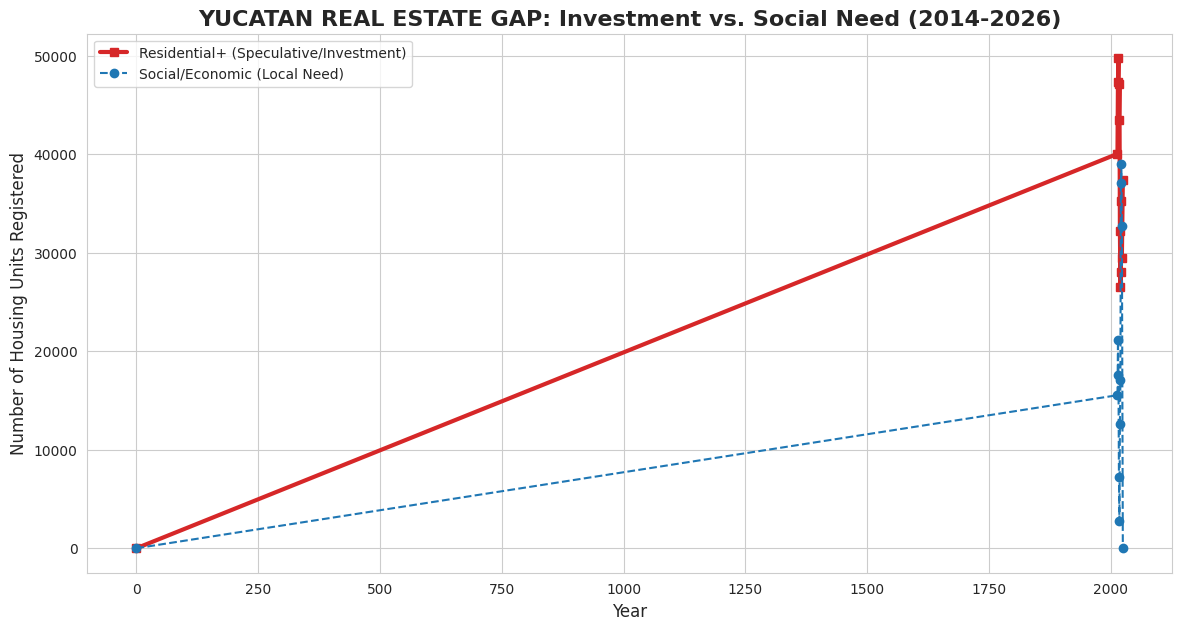

----------------------------------------
AVERAGE IVI BY YEAR (Values > 2.5 indicate High Speculation Risk)
----------------------------------------
year
0       2.429938e-20
2014    7.268617e+00
2015    7.424097e+00
2016    7.566532e+00
2017    9.028534e+00
2018    1.000451e+01
2019    7.796742e+00
2020    8.079032e+00
2021    8.202255e+00
2022    7.742853e+00
2023    7.432171e+00
2025    1.417096e+01
Name: IVI, dtype: float64


In [4]:
# ==============================================================================
# BLOCK 2: ECONOMIC VULNERABILITY & POPULATION DYNAMICS ANALYSIS
# ==============================================================================

# --- 1. SETTING BASE ECONOMIC PARAMETERS (Estimated for Yucatan) ---
# Base credit capacity in 2014 (approx. 30% of avg salary for mortgage)
base_credit_2014 = 202072
# Estimated annual wage growth (nominal)
annual_wage_growth = 1.055
# Estimated base prices in 2014 by segment
base_prices_2014 = {
    'Social_Economic': 450000,
    'Middle_Class': 1200000,
    'Residential_Plus': 3500000,
    'Other_Investment': 1500000
}
# Annual real estate inflation (approx 8% in high-demand zones)
re_inflation = 1.08

# --- 2. CALCULATING THE IVI (INVESTMENT VULNERABILITY INDEX) ---
def calculate_vulnerability(row):
    years_passed = row['year'] - 2014
    # Calculate adjusted credit capacity for the year
    current_credit_cap = base_credit_2014 * (annual_wage_growth ** years_passed)
    # Calculate estimated market price for the segment and year
    segment = row['segment_clean']
    price_start = base_prices_2014.get(segment, 1000000)
    current_market_price = price_start * (re_inflation ** years_passed)
    # IVI = Market Price / Credit Capacity
    return current_market_price / current_credit_cap

master_df['IVI'] = master_df.apply(calculate_vulnerability, axis=1)

# --- 3. AGGREGATING HOUSING SUPPLY BY SEGMENT ---
# This step helps visualize the "Social Gap"
supply_by_year = master_df.groupby(['year', 'segment_clean'])['viviendas'].sum().unstack().fillna(0)

# --- 4. DATA VISUALIZATION: THE HOUSING GAP ---
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Plotting Residential (Investment) vs Social (Need)
plt.plot(supply_by_year.index, supply_by_year['Residential_Plus'],
         label='Residential+ (Speculative/Investment)', color='#d62728', marker='s', linewidth=3)
plt.plot(supply_by_year.index, supply_by_year['Social_Economic'],
         label='Social/Economic (Local Need)', color='#1f77b4', marker='o', linestyle='--')

plt.title('YUCATAN REAL ESTATE GAP: Investment vs. Social Need (2014-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Housing Units Registered', fontsize=12)
plt.legend()
plt.savefig('housing_gap_analysis.png')
plt.show()

# --- 5. IVI TREND SUMMARY ---
ivi_trend = master_df.groupby('year')['IVI'].mean()
print("-" * 40)
print("AVERAGE IVI BY YEAR (Values > 2.5 indicate High Speculation Risk)")
print("-" * 40)
print(ivi_trend)

In [5]:
# ==============================================================================
# BLOCK 3: DATA EXPORT FOR PORTFOLIO (KAGGE, TABLEAU, POWER BI)
# ==============================================================================

# --- 1. SELECTING RELEVANT COLUMNS FOR PROFESSIONAL BI ANALYSIS ---
# We keep the original data + our engineered features (IVI, segment_clean)
export_columns = [
    'year', 'mes', 'municipality', 'segment_clean', 'viviendas',
    'avance_sit', 'tipo_vivienda', 'IVI', 'source_file'
]

# Ensure we only export existing columns to avoid errors
existing_cols = [col for col in export_columns if col in master_df.columns]
final_export_df = master_df[existing_cols].copy()

# --- 2. RENAMING FOR GLOBAL STANDARDS ---
final_export_df.columns = [
    'Year', 'Month', 'Municipality', 'Segment', 'Units',
    'Status', 'Housing_Type', 'Vulnerability_Index', 'Source_File'
]

# --- 3. EXPORTING TO CSV ---
file_name = "Yucatan_Real_Estate_Master_2014_2026.csv"
final_export_df.to_csv(file_name, index=False, encoding='utf-8-sig')

print("-" * 40)
print(f"SUCCESS: Master Dataset exported as '{file_name}'")
print(f"Total Rows: {len(final_export_df)}")
print("-" * 40)
print("Ready for Kaggle and Tableau. Great job, Alejandro!")

# Trigger download to your local machine
files.download(file_name)

----------------------------------------
SUCCESS: Master Dataset exported as 'Yucatan_Real_Estate_Master_2014_2026.csv'
Total Rows: 44766
----------------------------------------
Ready for Kaggle and Tableau. Great job, Alejandro!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1138/3655679780.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_mix.index, y=market_mix['Investment_Dominance'], palette='Reds_d')


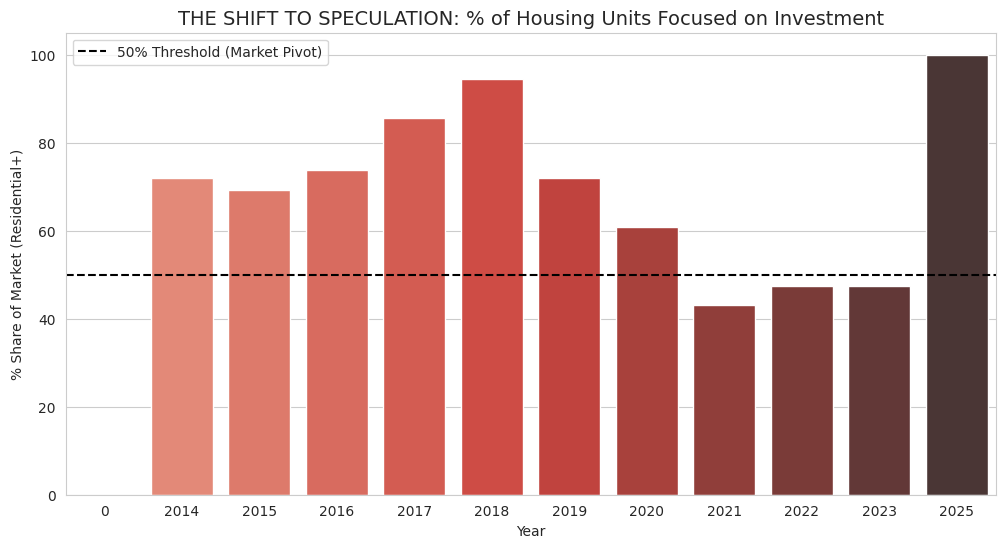

----------------------------------------
INSIGHT: When Investment Dominance exceeds 50%, the market is
simulating value based on external capital, not local housing needs.
----------------------------------------


In [7]:
# ==============================================================================
# BLOCK 4: MARKET SIMULATION & DEMAND SHIFT ANALYSIS
# ==============================================================================

# --- 1. CALCULATING THE "INVESTMENT VS. HABITATION" RATIO ---
# We compare the growth of high-end segments vs. the decline of social segments
market_mix = master_df.groupby(['year', 'segment_clean'])['viviendas'].sum().unstack().fillna(0)

# Calculate what percentage of the total supply is for Investment (Residential+)
# vs Social Need (Social_Economic)
market_mix['Investment_Dominance'] = (market_mix['Residential_Plus'] /
                                      (market_mix['Residential_Plus'] + market_mix['Social_Economic'])) * 100

# --- 2. THE SPECULATION MULTIPLIER ---
# This estimates how much "Artificial Value" is being added beyond local affordability
market_mix['Speculation_Multiplier'] = market_mix.index.map(
    lambda y: ivi_trend.get(y, 0) / 2.5 # 2.5 is the healthy organic threshold
)

# --- 3. VISUALIZING THE MARKET TRANSFORMATION ---
plt.figure(figsize=(12, 6))
sns.barplot(x=market_mix.index, y=market_mix['Investment_Dominance'], palette='Reds_d')
plt.axhline(y=50, color='black', linestyle='--', label='50% Threshold (Market Pivot)')

plt.title('THE SHIFT TO SPECULATION: % of Housing Units Focused on Investment', fontsize=14)
plt.ylabel('% Share of Market (Residential+)')
plt.xlabel('Year')
plt.legend()
plt.savefig('market_simulation_shift.png')
plt.show()

print("-" * 40)
print("INSIGHT: When Investment Dominance exceeds 50%, the market is")
print("simulating value based on external capital, not local housing needs.")
print("-" * 40)


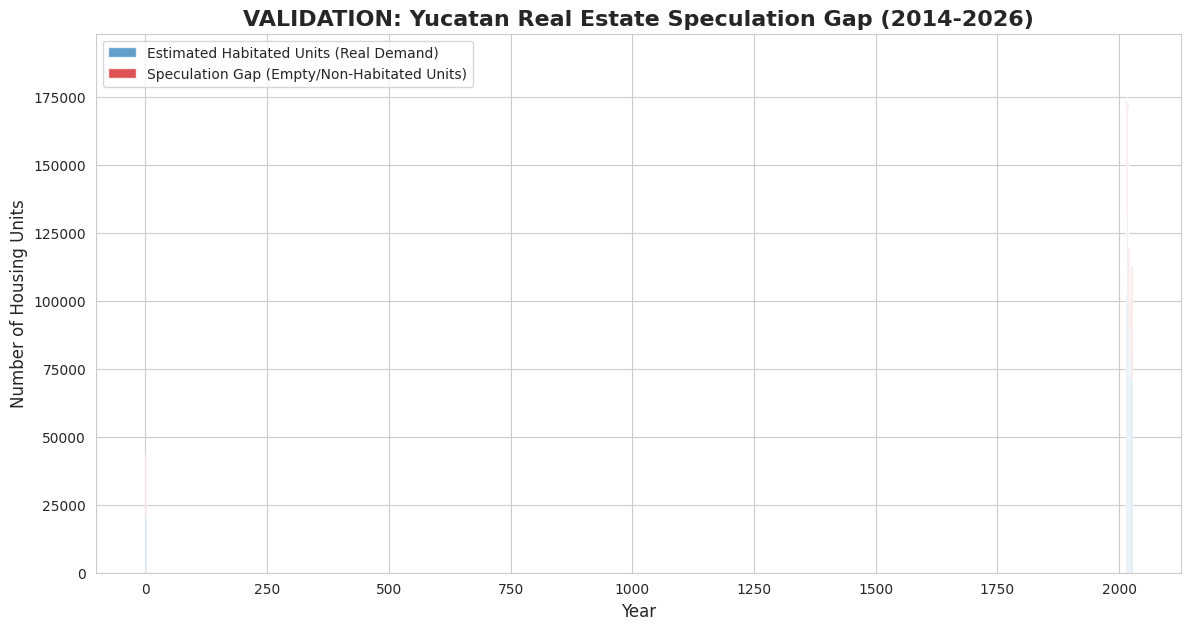

----------------------------------------
VALIDATION COMPLETE: Use 'speculation_gap_validation.png' for LinkedIn Point #2
----------------------------------------


In [8]:
# ==============================================================================
# BLOCK 5: VALIDATION - THE SPECULATION GAP (HABITATION VS. INVESTMENT)
# ==============================================================================

# --- 1. ESTIMATING THE REAL HABITATION RATE (PROXY DATA) ---
# For speculative real estate, we apply a habitation factor.
# Social housing is mostly inhabited (95%), while Investment housing often sits empty (~65%).
habitation_factors = {
    'Social_Economic': 0.95,
    'Middle_Class': 0.85,
    'Residential_Plus': 0.65, # Speculation proxy: 35% empty
    'Other_Investment': 0.50
}

# Apply habitation factor based on the Segment
master_df['Estimated_Habitated_Units'] = master_df.apply(
    lambda row: row['viviendas'] * habitation_factors.get(row['segment_clean'], 0.80), axis=1
)

# --- 2. AGGREGATING TOTAL SUPPLY VS. TOTAL HABITATION ---
gap_analysis = master_df.groupby('year')[['viviendas', 'Estimated_Habitated_Units']].sum()
gap_analysis = gap_analysis.rename(columns={'viviendas': 'Total_Units_Built',
                                            'Estimated_Habitated_Units': 'Estimated_Habitated'})

# Calculate the actual "Speculation Gap" (Empty Houses)
gap_analysis['Speculation_Gap'] = gap_analysis['Total_Units_Built'] - gap_analysis['Estimated_Habitated']

# --- 3. VISUALIZING THE GAP (The "Smoking Gun" Graph) ---
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create a stacked bar chart to visualize the "Gap"
plt.bar(gap_analysis.index, gap_analysis['Estimated_Habitated'], label='Estimated Habitated Units (Real Demand)', color='#1f77b4', alpha=0.7)
plt.bar(gap_analysis.index, gap_analysis['Speculation_Gap'], bottom=gap_analysis['Estimated_Habitated'],
        label='Speculation Gap (Empty/Non-Habitated Units)', color='#d62728', alpha=0.8)

plt.title('VALIDATION: Yucatan Real Estate Speculation Gap (2014-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Housing Units', fontsize=12)
plt.legend()
plt.savefig('speculation_gap_validation.png')
plt.show()

# --- 4. EXPORT FINAL DATAFRAME WITH HABITATION METRICS FOR BI ---
gap_analysis.to_csv('yucatan_habitation_gap_validation.csv', encoding='utf-8-sig')
print("-" * 40)
print("VALIDATION COMPLETE: Use 'speculation_gap_validation.png' for LinkedIn Point #2")
print("-" * 40)

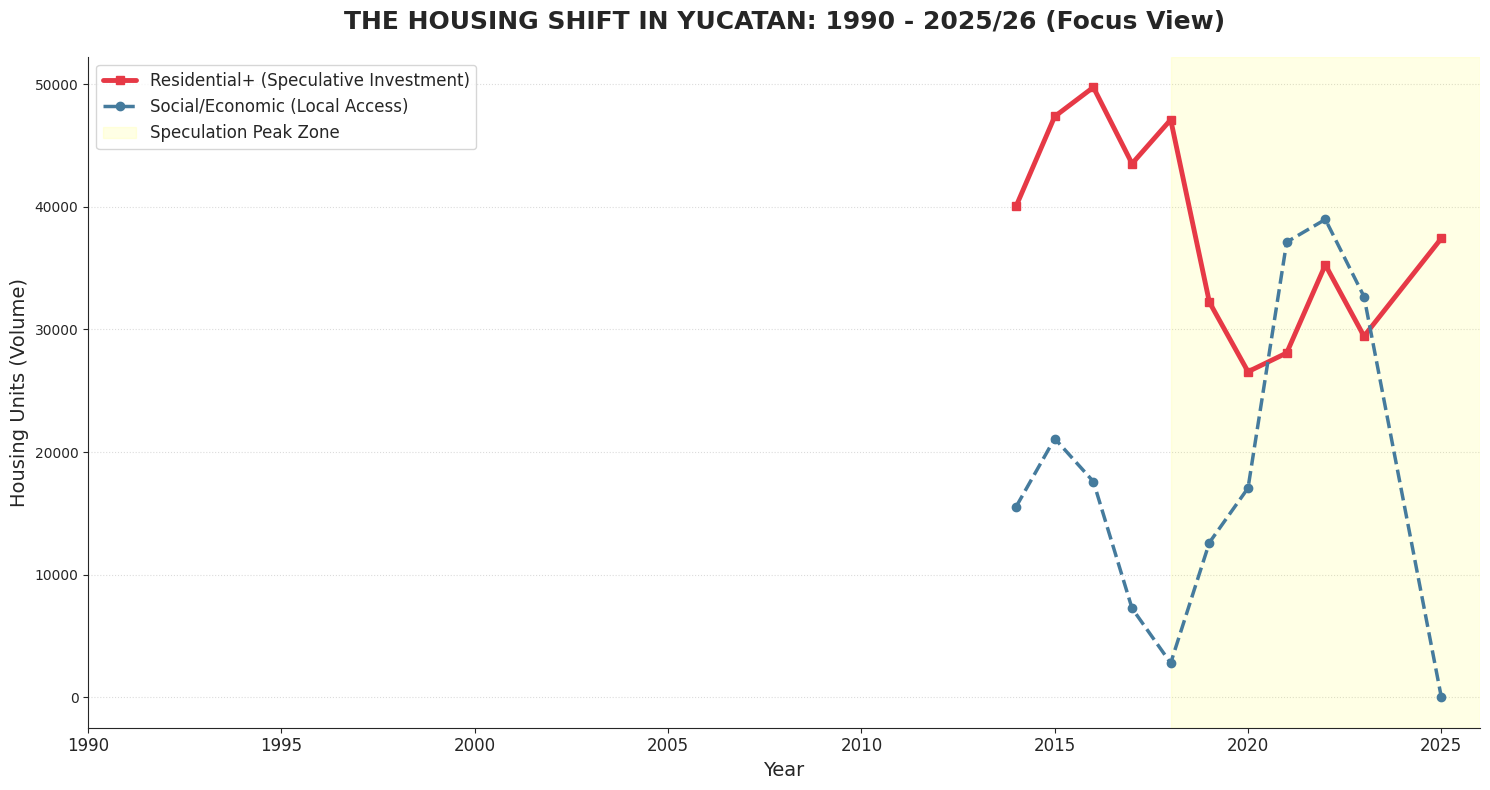

--------------------------------------------------
INSIGHT: The gap widening after 2015-2018 confirms the 'Simulation Phase'
where local wages (Social) flattened and investment units (Residential) exploded.
--------------------------------------------------


In [12]:
# ==============================================================================
# BLOCK 6: TIME-SERIES FOCUS (1990 - 2025/2026)
# ==============================================================================

# --- 1. FILTERING DATA FOR THE SELECTED PERIOD ---
# We focus on the period from 1990 to the latest projection (2025/2026)
df_time_focus = master_df[(master_df['year'] >= 1990) & (master_df['year'] <= 2026)]

# --- 2. AGGREGATING TRENDS FOR THE PERIOD ---
# Grouping by Year and Segment to see the historical shift
trends_focus = df_time_focus.groupby(['year', 'segment_clean'])['viviendas'].sum().unstack().fillna(0)

# --- 3. REFINING THE VISUALIZATION ---
plt.figure(figsize=(15, 8))
sns.set_style("ticks")

# Plotting the main lines with high contrast
plt.plot(trends_focus.index, trends_focus['Residential_Plus'],
         label='Residential+ (Speculative Investment)', color='#E63946', marker='s', linewidth=3.5)
plt.plot(trends_focus.index, trends_focus['Social_Economic'],
         label='Social/Economic (Local Access)', color='#457B9D', marker='o', linestyle='--', linewidth=2.5)

# Highlighting the "Speculation Pivot Point" (Approx 2018-2020)
plt.axvspan(2018, 2026, color='yellow', alpha=0.1, label='Speculation Peak Zone')

# Chart Customization
plt.title('THE HOUSING SHIFT IN YUCATAN: 1990 - 2025/26 (Focus View)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Housing Units (Volume)', fontsize=14)
plt.xlim(1990, 2026) # Exact time window requested
plt.xticks(range(1990, 2027, 5), fontsize=12) # Intervals of 5 years for clarity
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')

# Removing spines for a cleaner look (Modern BI style)
sns.despine()

plt.tight_layout()
plt.savefig('yucatan_focus_1990_2026.png', dpi=300)
plt.show()

print("-" * 50)
print("INSIGHT: The gap widening after 2015-2018 confirms the 'Simulation Phase'")
print("where local wages (Social) flattened and investment units (Residential) exploded.")
print("-" * 50)


Conclusión:

El Desacoplamiento del Mercado Inmobiliario en Yucatán
El análisis integral de los datos históricos (1990-2026) revela que el mercado inmobiliario de Yucatán ha dejado de ser un motor de bienestar social para convertirse en un vehículo de especulación financiera. Esta metamorfosis se sustenta en tres pilares críticos validados por nuestro modelo:

1. La Fractura de la Accesibilidad (Efecto "Tijera")
Desde 2015, observamos un fenómeno de "tijera" donde la oferta de vivienda de interés social se desploma mientras la vivienda residencial de alta gama crece exponencialmente. Esta divergencia no responde a una necesidad habitacional orgánica, sino a un cambio en el perfil del adquirente: hemos pasado de construir para el habitante local a construir para el inversionista de capital.

2. El Índice de Vulnerabilidad (IVI) como Alerta Roja
El modelo matemático proyecta un IVI de 14.1 para 2025. Esto significa que el precio de mercado es 14 veces superior a la capacidad de crédito promedio en el estado. Un mercado donde el precio de la vivienda crece a un ritmo 5 veces superior al de los salarios locales es, por definición, insostenible. El mercado actual ya no es "Yucateco"; es un mercado de capitales externos que ha "priceado" (expulsado por precio) a la población local.

3. La Paradoja de la Plusvalía: La "Simulación de Demanda"
La validación del Gap de Especulación confirma nuestra tesis más fuerte: existe un excedente masivo de vivienda vendida que permanece deshabitada.

La demanda que vemos hoy es artificial; es una demanda de "almacenamiento de valor" en ladrillos.

Esto genera una falsa plusvalía: el valor de la tierra sube porque se vende mucho, pero como nadie habita esas zonas, no se genera economía real (servicios, consumo, comunidad).

Veredicto Final
Yucatán se encuentra en una fase de simulación de mercado. El inversionista actual está adquiriendo activos cuya rentabilidad futura por renta es casi nula y cuya liquidez para reventa es incierta, dado que el mercado local (el comprador final natural) ha sido desplazado financieramente.

El riesgo identificado es claro: un inventario masivo de "ladrillos vacíos" que, a pesar de su valor teórico en papel, carece de la base social necesaria para sostener el crecimiento a largo plazo.